# Imports

In [1]:
import os
import glob
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

warnings.filterwarnings('ignore')

# Reading the Data

In [2]:
# Define the zip file pattern
zip_pattern = "data/experiment_data_P0*.zip"

# Lists to store the parsed data
all_csv_trials = []
all_clicks = []
all_mouse_samples = []
all_demographics = []
raw_json_data = []

# Iterate through all zip files matching the pattern
for zip_path in glob.glob(zip_pattern):
    if os.path.exists(zip_path):
        print(f"Processing {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            # Identify the specific JSON and CSV files inside this zip
            file_names = z.namelist()
            json_filename = next((f for f in file_names if f.endswith('.json')), None)
            csv_filename = next((f for f in file_names if f.endswith('.csv')), None)

            # Read and process the CSV file (trial summary)
            if csv_filename:
                with z.open(csv_filename) as csv_file:
                    df_csv = pd.read_csv(csv_file)
                    all_csv_trials.append(df_csv)

            # Read and process the JSON file
            if json_filename:
                with z.open(json_filename) as json_file:
                    data = json.loads(json_file.read().decode('utf-8'))
                    raw_json_data.append(data)

                    p_code = data.get('participant_code', 'Unknown')

                    # Extract Demographics
                    demo = data.get('demographics', {})
                    # Add the participant code so we can merge it later
                    demo['participant_code'] = p_code
                    all_demographics.append(demo)

                    # Flatten click_events
                    if 'click_events' in data:
                        for click in data['click_events']:
                            click['participant_code'] = p_code
                            all_clicks.append(click)

                    # Flatten mouse_samples
                    if 'mouse_samples' in data:
                        for sample in data['mouse_samples']:
                            sample['participant_code'] = p_code
                            all_mouse_samples.append(sample)

print(f"Successfully processed {len(raw_json_data)} participant zip files.")

Processing data\experiment_data_P001.zip...
Processing data\experiment_data_P002.zip...
Processing data\experiment_data_P003.zip...
Processing data\experiment_data_P004.zip...
Processing data\experiment_data_P005.zip...
Processing data\experiment_data_P006.zip...
Processing data\experiment_data_P007.zip...
Processing data\experiment_data_P008.zip...
Processing data\experiment_data_P009.zip...
Processing data\experiment_data_P010.zip...
Processing data\experiment_data_P011.zip...
Processing data\experiment_data_P012.zip...
Processing data\experiment_data_P013.zip...
Processing data\experiment_data_P014.zip...
Processing data\experiment_data_P015.zip...
Processing data\experiment_data_P016.zip...
Processing data\experiment_data_P017.zip...
Processing data\experiment_data_P018.zip...
Processing data\experiment_data_P019.zip...
Processing data\experiment_data_P020.zip...
Processing data\experiment_data_P021.zip...
Successfully processed 21 participant zip files.


In [3]:
# Combine everything into master pandas DataFrames
if all_csv_trials:
    df_trials = pd.concat(all_csv_trials, ignore_index=True)
else:
    df_trials = pd.DataFrame()

df_clicks = pd.DataFrame(all_clicks)
df_mouse = pd.DataFrame(all_mouse_samples)
df_demographics = pd.DataFrame(all_demographics)

def convert_df_to_numeric(df):
    for col in df.columns:
        # Attempts to convert to number
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

df_trials = convert_df_to_numeric(df_trials)
df_clicks = convert_df_to_numeric(df_clicks)
df_mouse = convert_df_to_numeric(df_mouse)
df_demographics = convert_df_to_numeric(df_demographics)

print(f"Created df_trials with {len(df_trials)} rows from the CSVs.")
print(f"Created df_clicks with {len(df_clicks)} rows from the JSONs.")
print(f"Created df_mouse with {len(df_mouse)} rows from the JSONs.")
print(f"Created df_demographics with {len(df_demographics)} rows from the JSONs.")

Created df_trials with 252 rows from the CSVs.
Created df_clicks with 1638 rows from the JSONs.
Created df_mouse with 327555 rows from the JSONs.
Created df_demographics with 21 rows from the JSONs.


In [4]:
df_trials.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,participant_yes_button_side,participant_no_button_side,response_side_assignment_method,presentation_order_method,counterbalance_index,...,total_mouse_distance_confidence1,total_mouse_distance_phase3,total_mouse_distance_confidence2,number_of_pauses_phase1,number_of_pauses_phase3,number_of_direction_changes_phase1,number_of_direction_changes_phase3,dwell_time_yes_button_ms,dwell_time_no_button_ms,dwell_time_confidence_scale_ms
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,696,379,561,2,2,0,0,865,0,1449
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,519,341,644,4,4,0,0,1486,547,1351
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,581,433,927,2,2,0,0,2881,0,1900
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,461,478,492,3,3,5,0,602,511,1326
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,left,right,fixed_by_participant_code,latin_square_counterbalancing,0,...,572,887,679,2,5,0,1,1359,483,2300


In [5]:
df_clicks.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,clicked_element,click_timestamp_ms,x,y
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,trial_start,start_trial_button,125945,613,399
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,yes_button,130033,229,575
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,confidence1,confidence_scale,132603,723,395
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,center_before_final,center_continue_button,136131,640,392
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,final_answer,yes_button,149957,341,546


In [6]:
df_mouse.head()

,participant_number,participant_id,participant_code,session_id,assigned_condition,trial_index,problem_id,phase,timestamp_ms_from_experiment_start,timestamp_ms_from_phase_start,x,y,viewport_width,viewport_height,element_or_zone,countdown_time_remaining_ms,mouse_button_down
0,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125972,26,613,399,1163,654,problem_text,9974.0,False
1,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,125996,51,613,399,1163,654,problem_text,9950.0,False
2,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126023,77,613,399,1163,654,problem_text,9923.0,False
3,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126046,101,613,399,1163,654,problem_text,9899.0,False
4,1,P_20260622185812_9ijiw,P001,S_20260622185812_gx8xgfxq,soft,1,T02,first_answer,126071,126,613,399,1163,654,problem_text,9874.0,False


In [7]:
df_demographics.head()

,participant_code,age,gender,native_language,english_proficiency,logic_experience,dominant_hand,input_device,vision_status,motor_difficulty
0,P001,22,Woman,Portuguese,5,2,Right,Touchpad,Corrected with glasses/contact lenses,No
1,P002,23,Woman,arabic,4,5,Right,Touchpad,Normal,No
2,P003,26,Man,Hebrew,5,3,Right,Touchpad,Corrected with glasses/contact lenses,No
3,P004,21,Woman,Hebrew,5,4,Right,Touchpad,Normal,No
4,P005,23,Woman,Arabic,5,4,Left,Other,Corrected with glasses/contact lenses,No


In [8]:
# Normalize languages
df_demographics['native_language'] = df_demographics['native_language'].str.lower().str.strip().str.title()
# Replace `heb` with `Hebrew`
df_demographics['native_language'] = df_demographics['native_language'].replace({'Heb': 'Hebrew'})

# Data Exploration

## Demographics

In [9]:
df_trials.groupby(['participant_code','assigned_condition']).first().reset_index()['assigned_condition'].value_counts()

assigned_condition
soft      11
strict    10
Name: count, dtype: int64

In [10]:
participant_conditions = df_trials.groupby(['participant_code','assigned_condition']).first().reset_index()[['participant_code','assigned_condition', 'participant_yes_button_side']]

In [11]:
participant_conditions

,participant_code,assigned_condition,participant_yes_button_side
0,P001,soft,left
1,P002,strict,left
2,P003,soft,right
3,P004,strict,right
4,P005,soft,left
5,P006,soft,right
6,P007,soft,right
7,P008,strict,right
8,P009,soft,left
9,P010,strict,left


In [12]:
# Check for gender distribution in each condition
genders_under_cond = df_demographics.merge(participant_conditions, on='participant_code', how='left').groupby(['assigned_condition', 'gender']).count()
genders_under_cond

participant_code  age  native_language  \
assigned_condition gender                                           
soft               Man                    7    7                7   
                   Woman                  4    4                4   
strict             Man                    4    4                4   
                   Woman                  6    6                6   

                           english_proficiency  logic_experience  \
assigned_condition gender                                          
soft               Man                       7                 7   
                   Woman                     4                 4   
strict             Man                       4                 4   
                   Woman                     6                 6   

                           dominant_hand  input_device  vision_status  \
assigned_condition gender                                               
soft               Man                 7             7              7   
                   Woman               4             4              4   
strict             Man                 4             4              4   
                   Woman               6             6              6   

                           motor_difficulty  participant_yes_button_side  
assigned_condition gender                                                 
soft               Man                    7                            7  
                   Woman                  4                            4  
strict             Man                    4                            4  
                   Woman                  6                            6

In [13]:
def plot_hist(df, column, title, xlabel, ylabel, bins=10, color='skyblue'):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=bins, kde=True, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column}: M={df[column].mean():.2f}, SD={df[column].std():.2f}")

In [14]:
def plot_bar(df, column, title, xlabel, ylabel):
    plt.figure(figsize=(8, 5))
    value_counts = df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='pastel')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    print(f"{column} value counts:\n{value_counts}")

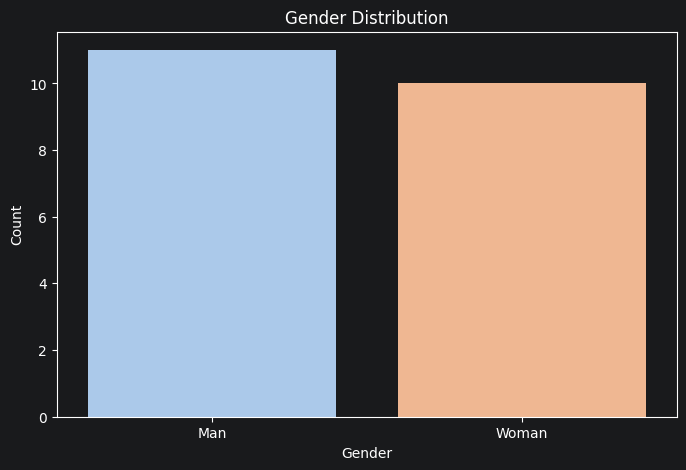

gender value counts:
gender
Man      11
Woman    10
Name: count, dtype: int64


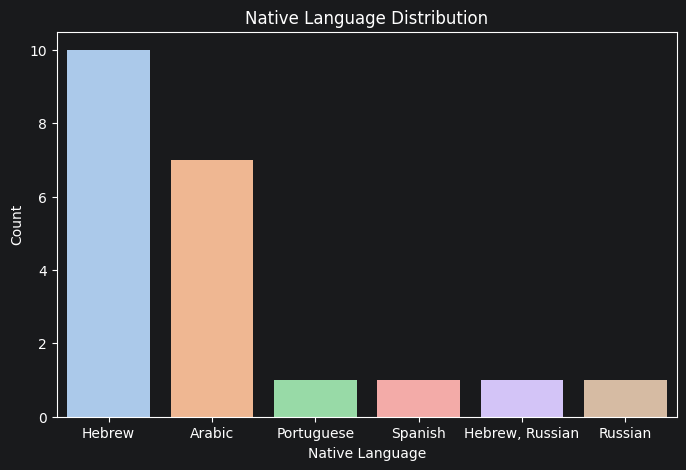

native_language value counts:
native_language
Hebrew             10
Arabic              7
Portuguese          1
Spanish             1
Hebrew, Russian     1
Russian             1
Name: count, dtype: int64


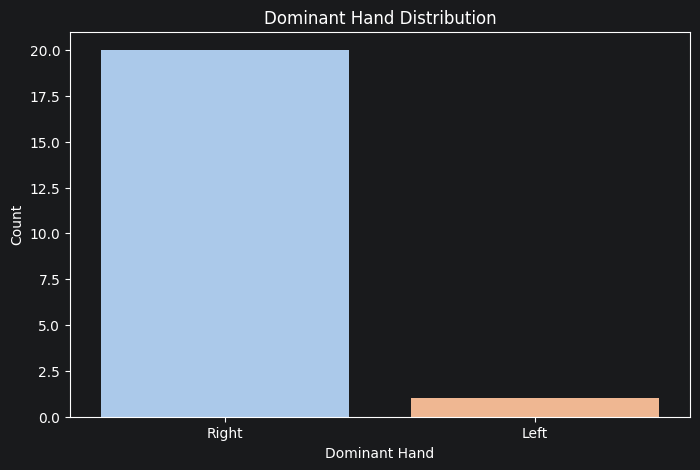

dominant_hand value counts:
dominant_hand
Right    20
Left      1
Name: count, dtype: int64


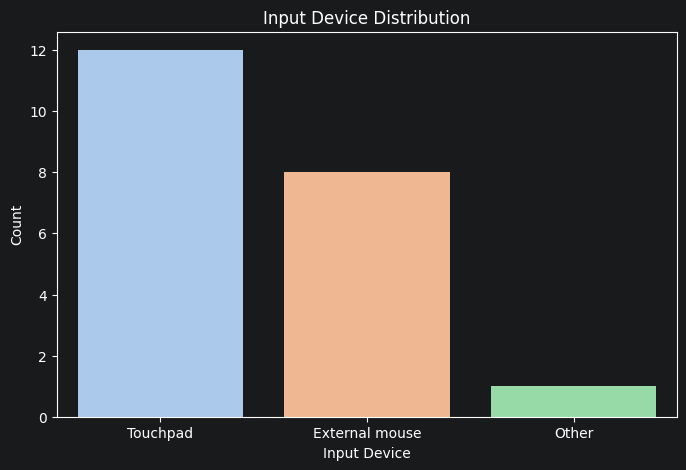

input_device value counts:
input_device
Touchpad          12
External mouse     8
Other              1
Name: count, dtype: int64


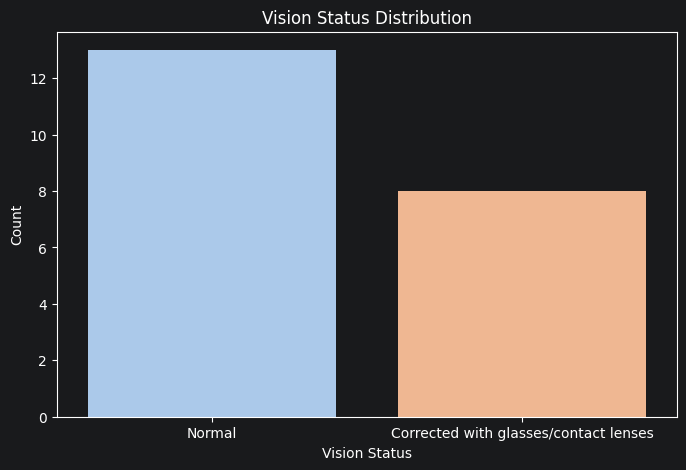

vision_status value counts:
vision_status
Normal                                   13
Corrected with glasses/contact lenses     8
Name: count, dtype: int64


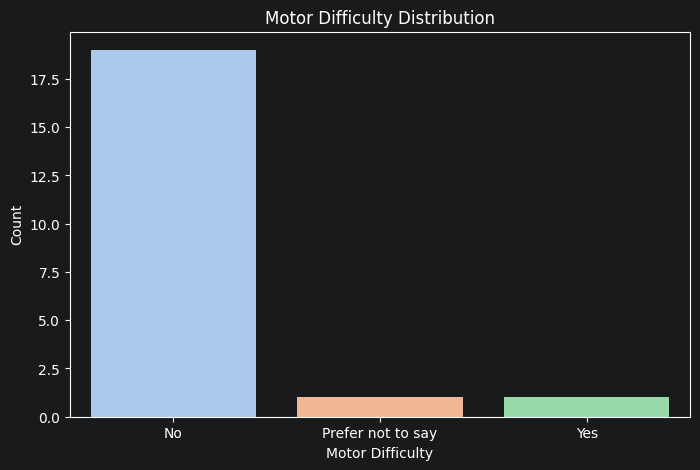

motor_difficulty value counts:
motor_difficulty
No                   19
Prefer not to say     1
Yes                   1
Name: count, dtype: int64


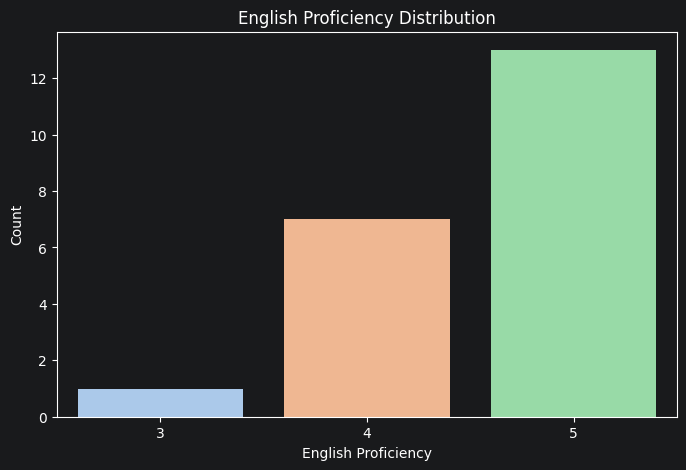

english_proficiency value counts:
english_proficiency
5    13
4     7
3     1
Name: count, dtype: int64


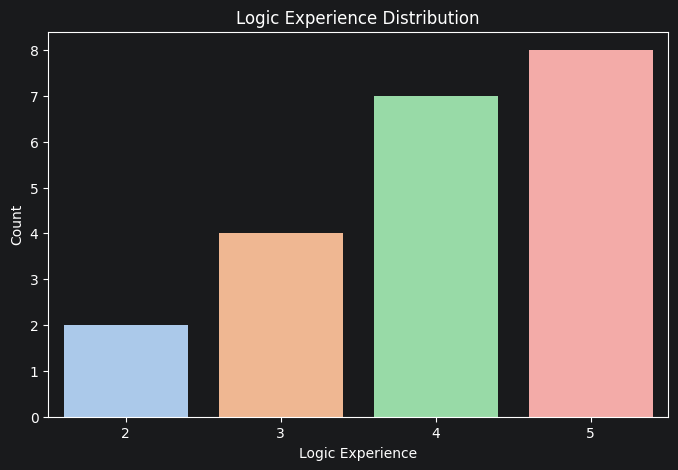

logic_experience value counts:
logic_experience
5    8
4    7
3    4
2    2
Name: count, dtype: int64


In [15]:
bar_cols = ['gender', 'native_language', 'dominant_hand', 'input_device', 'vision_status', 'motor_difficulty', 'english_proficiency', 'logic_experience']
for col in bar_cols:
    plot_bar(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')

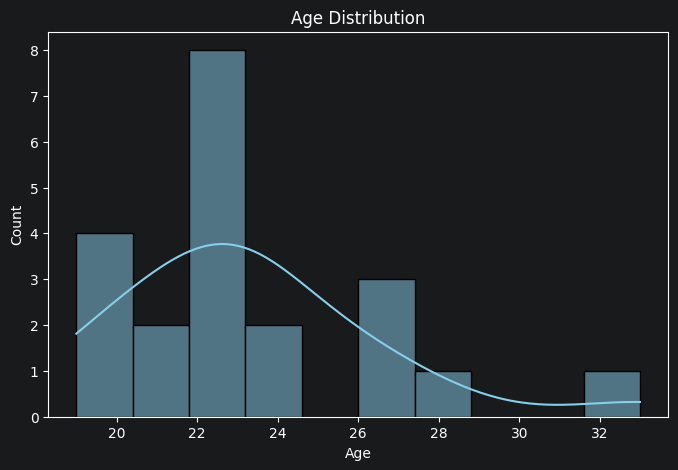

age: M=23.29, SD=3.26


In [16]:
hist_cols = ['age']
for col in hist_cols:
    plot_hist(df_demographics, col, f'{col.replace("_", " ").title()} Distribution', col.replace("_", " ").title(), 'Count')

# Metric Analysis

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Binary Acceptance Tracking
df_trials['accept_phase1'] = df_trials['response1'].map({'YES': 1, 'NO': 0})
df_trials['accept_phase2'] = df_trials['final_response'].map({'YES': 1, 'NO': 0})

# 2. Answer Change Direction Tracking
df_trials['answer_changed'] = (df_trials['response1'] != df_trials['final_response']).astype(int)
df_trials['yes_to_no'] = ((df_trials['response1'] == 'YES') & (df_trials['final_response'] == 'NO')).astype(int)
df_trials['no_to_yes'] = ((df_trials['response1'] == 'NO') & (df_trials['final_response'] == 'YES')).astype(int)

# Helper for Logic Index (Valid Acceptance - Invalid Acceptance)
def calc_logic_index(group, resp_col):
    valid_accept = group[group['validity'] == 'valid'][resp_col].mean()
    invalid_accept = group[group['validity'] == 'invalid'][resp_col].mean()
    return valid_accept - invalid_accept

# Helper for Confidence
def get_conf(group, phase):
    for p in ['confidence', 'conf']:
        for suffix in [str(phase), f'_{phase}', f'phase{phase}', f'_phase{phase}']:
            col = f'{p}{suffix}'
            if col in group.columns: return group[col].mean()
    return np.nan

# 3. Aggregate all metrics per participant
def aggregate_participant(group):
    li1 = calc_logic_index(group, 'accept_phase1')
    li2 = calc_logic_index(group, 'accept_phase2')

    # Extract exact RT columns and convert milliseconds to seconds
    rt1 = group['response1_rt_ms'].mean() / 1000 if 'response1_rt_ms' in group.columns else np.nan
    rt2 = group['final_rt_ms'].mean() / 1000 if 'final_rt_ms' in group.columns else np.nan

    return pd.Series({
        'assigned_condition': group['assigned_condition'].iloc[0],
        'accept_1': group['accept_phase1'].mean(),
        'accept_2': group['accept_phase2'].mean(),
        'answer_changed': group['answer_changed'].mean(),
        'yes_to_no': group['yes_to_no'].mean(),
        'no_to_yes': group['no_to_yes'].mean(),
        'logic_index_1': li1,
        'logic_index_2': li2,
        'accuracy_increase': li2 - li1,
        'confidence_1': get_conf(group, 1),
        'confidence_2': get_conf(group, 2),
        'rt_1': rt1,
        'rt_2': rt2
    })

df_p = df_trials.groupby('participant_code').apply(aggregate_participant).reset_index()

# 4. Label 'Good' and 'Poor' reasoners based on overall median split of final Logic Index
median_li2 = df_p['logic_index_2'].median()
df_p['reasoner_type'] = np.where(df_p['logic_index_2'] >= median_li2, 'Good', 'Poor')

print(f"Data successfully aggregated for {len(df_p)} participants.")
print(f"Median Logic Index (Phase 2) used for Good/Poor split: {median_li2:.3f}")

Data successfully aggregated for 21 participants.
Median Logic Index (Phase 2) used for Good/Poor split: 0.500


In [28]:
print("==========================================================")
print(" PART 1: REPLICATION OF MAIN CONCLUSIONS (OVERALL SAMPLE) ")
print("==========================================================\n")

# 1. Yes Bias
print("1. OVERALL YES BIAS (Chance = 50%)")
overall_accept = df_p['accept_2'].mean()
t_stat, p_val = stats.ttest_1samp(df_p['accept_2'].dropna(), 0.5)
print(f"-> Mean Conclusion Acceptance Rate: {overall_accept*100:.1f}%")
print(f"-> One-sample t-test vs 0.5: t({len(df_p)-1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

# 2. Answer Change Direction
print("2. DIRECTION OF ANSWER CHANGES")
print(f"-> Mean NO to YES: {df_p['no_to_yes'].mean()*100:.1f}% | Mean YES to NO: {df_p['yes_to_no'].mean()*100:.1f}%")
t_stat, p_val = stats.ttest_rel(df_p['yes_to_no'], df_p['no_to_yes'])
print(f"-> Paired t-test: t({len(df_p)-1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

# 3. Accuracy of Good vs Poor Reasoners
print("3. ACCURACY BY REASONING ABILITY (Chance = 0)")
good_acc = df_p[df_p['reasoner_type'] == 'Good']['logic_index_2'].dropna()
poor_acc = df_p[df_p['reasoner_type'] == 'Poor']['logic_index_2'].dropna()
t_good, p_good = stats.ttest_1samp(good_acc, 0)
t_poor, p_poor = stats.ttest_1samp(poor_acc, 0)
print(f"-> Good Reasoners: M = {good_acc.mean():.3f} | t = {t_good:.3f}, p = {p_good:.4f}")
print(f"-> Poor Reasoners: M = {poor_acc.mean():.3f} | t = {t_poor:.3f}, p = {p_poor:.4f}\n")

# 4. Accuracy Increase
print("4. ACCURACY INCREASE (RESPONSE 1 TO 2)")
t_stat, p_val = stats.ttest_rel(df_p['logic_index_2'].dropna(), df_p['logic_index_1'].dropna())
print(f"-> Phase 1 Acc: {df_p['logic_index_1'].mean():.3f} | Phase 2 Acc: {df_p['logic_index_2'].mean():.3f}")
print(f"-> Paired t-test: t({len(df_p)-1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

# 5. Confidence Increase
if df_p['confidence_1'].notna().any():
    print("5. CONFIDENCE INCREASE (RESPONSE 1 TO 2)")
    t_stat, p_val = stats.ttest_rel(df_p['confidence_2'].dropna(), df_p['confidence_1'].dropna())
    print(f"-> Phase 1 Conf: {df_p['confidence_1'].mean():.3f} | Phase 2 Conf: {df_p['confidence_2'].mean():.3f}")
    print(f"-> Paired t-test: t({len(df_p)-1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

# 6. Response Time Increase (Paper Conclusion: RT increases during deliberation phase)
if df_p['rt_1'].notna().any():
    print("6. RESPONSE TIME INCREASE (RESPONSE 1 TO 2)")
    t_stat, p_val = stats.ttest_rel(df_p['rt_2'].dropna(), df_p['rt_1'].dropna())
    print(f"-> Phase 1 RT: {df_p['rt_1'].mean():.3f}s | Phase 2 RT: {df_p['rt_2'].mean():.3f}s")
    print(f"-> Paired t-test: t({len(df_p)-1}) = {t_stat:.3f}, p = {p_val:.4f}\n")

# 7. RT by Reasoning Ability (Paper Conclusion: Good and Poor reasoners spend same amount of time)
if df_p['rt_2'].notna().any():
    print("7. RESPONSE TIME BY REASONING ABILITY (PHASE 2)")
    good_rt = df_p[df_p['reasoner_type'] == 'Good']['rt_2'].dropna()
    poor_rt = df_p[df_p['reasoner_type'] == 'Poor']['rt_2'].dropna()
    t_stat, p_val = stats.ttest_ind(good_rt, poor_rt, equal_var=False)
    print(f"-> Good RT: {good_rt.mean():.3f}s | Poor RT: {poor_rt.mean():.3f}s")
    print(f"-> Independent t-test: t = {t_stat:.3f}, p = {p_val:.4f}\n")

 PART 1: REPLICATION OF MAIN CONCLUSIONS (OVERALL SAMPLE) 

1. OVERALL YES BIAS (Chance = 50%)
-> Mean Conclusion Acceptance Rate: 64.4%
-> One-sample t-test vs 0.5: t(20) = 3.851, p = 0.0010

2. DIRECTION OF ANSWER CHANGES
-> Mean NO to YES: 15.5% | Mean YES to NO: 14.7%
-> Paired t-test: t(20) = -0.180, p = 0.8591

3. ACCURACY BY REASONING ABILITY (Chance = 0)
-> Good Reasoners: M = 0.753 | t = 12.604, p = 0.0000
-> Poor Reasoners: M = 0.165 | t = 3.469, p = 0.0071

4. ACCURACY INCREASE (RESPONSE 1 TO 2)
-> Phase 1 Acc: 0.185 | Phase 2 Acc: 0.473
-> Paired t-test: t(20) = 3.798, p = 0.0011

5. CONFIDENCE INCREASE (RESPONSE 1 TO 2)
-> Phase 1 Conf: 3.736 | Phase 2 Conf: 5.909
-> Paired t-test: t(20) = 10.795, p = 0.0000

6. RESPONSE TIME INCREASE (RESPONSE 1 TO 2)
-> Phase 1 RT: 8.605s | Phase 2 RT: 21.164s
-> Paired t-test: t(20) = 5.630, p = 0.0000

7. RESPONSE TIME BY REASONING ABILITY (PHASE 2)
-> Good RT: 23.984s | Poor RT: 18.062s
-> Independent t-test: t = 1.304, p = 0.2087



In [29]:
print("==========================================================")
print(" PART 2: BETWEEN-CONDITIONS COMPARISON (SOFT VS STRICT)   ")
print("==========================================================\n")

strict_p = df_p[df_p['assigned_condition'] == 'strict']
soft_p = df_p[df_p['assigned_condition'] == 'soft']

def compare_conditions(metric, name, is_percentage=False):
    strict_data = strict_p[metric].dropna()
    soft_data = soft_p[metric].dropna()
    if len(strict_data) == 0 or len(soft_data) == 0: return

    t_stat, p_val = stats.ttest_ind(strict_data, soft_data, equal_var=False)
    print(f"--- {name.upper()} ---")
    if is_percentage:
        print(f"Strict: {strict_data.mean()*100:.1f}% | Soft: {soft_data.mean()*100:.1f}%")
    else:
        print(f"Strict: M = {strict_data.mean():.3f} | Soft: M = {soft_data.mean():.3f}")
    print(f"Independent t-test: t = {t_stat:.3f}, p = {p_val:.4f}\n")

compare_conditions('accept_2', 'Overall Acceptance Rate (Phase 2)', is_percentage=True)
compare_conditions('answer_changed', 'Total Answer Change Rate', is_percentage=True)
compare_conditions('yes_to_no', 'YES to NO Change Rate', is_percentage=True)
compare_conditions('no_to_yes', 'NO to YES Change Rate', is_percentage=True)
compare_conditions('logic_index_2', 'Accuracy (Logic Index Phase 2)')
compare_conditions('accuracy_increase', 'Accuracy Increase (Phase 2 - Phase 1)')

if df_p['confidence_2'].notna().any(): compare_conditions('confidence_2', 'Confidence (Phase 2)')
if df_p['rt_2'].notna().any(): compare_conditions('rt_2', 'Response Time (Phase 2)')

 PART 2: BETWEEN-CONDITIONS COMPARISON (SOFT VS STRICT)   

--- OVERALL ACCEPTANCE RATE (PHASE 2) ---
Strict: 64.4% | Soft: 64.4%
Independent t-test: t = 0.005, p = 0.9959

--- TOTAL ANSWER CHANGE RATE ---
Strict: 45.0% | Soft: 28.8%
Independent t-test: t = 2.160, p = 0.0438

--- YES TO NO CHANGE RATE ---
Strict: 14.2% | Soft: 15.2%
Independent t-test: t = -0.167, p = 0.8692

--- NO TO YES CHANGE RATE ---
Strict: 17.5% | Soft: 13.6%
Independent t-test: t = 0.652, p = 0.5258

--- ACCURACY (LOGIC INDEX PHASE 2) ---
Strict: M = 0.443 | Soft: M = 0.500
Independent t-test: t = -0.373, p = 0.7137

--- ACCURACY INCREASE (PHASE 2 - PHASE 1) ---
Strict: M = 0.305 | Soft: M = 0.273
Independent t-test: t = 0.210, p = 0.8356

--- CONFIDENCE (PHASE 2) ---
Strict: M = 5.717 | Soft: M = 6.083
Independent t-test: t = -0.949, p = 0.3544

--- RESPONSE TIME (PHASE 2) ---
Strict: M = 24.031 | Soft: M = 18.557
Independent t-test: t = 1.149, p = 0.2693



Generating Plots for SOFT Condition...


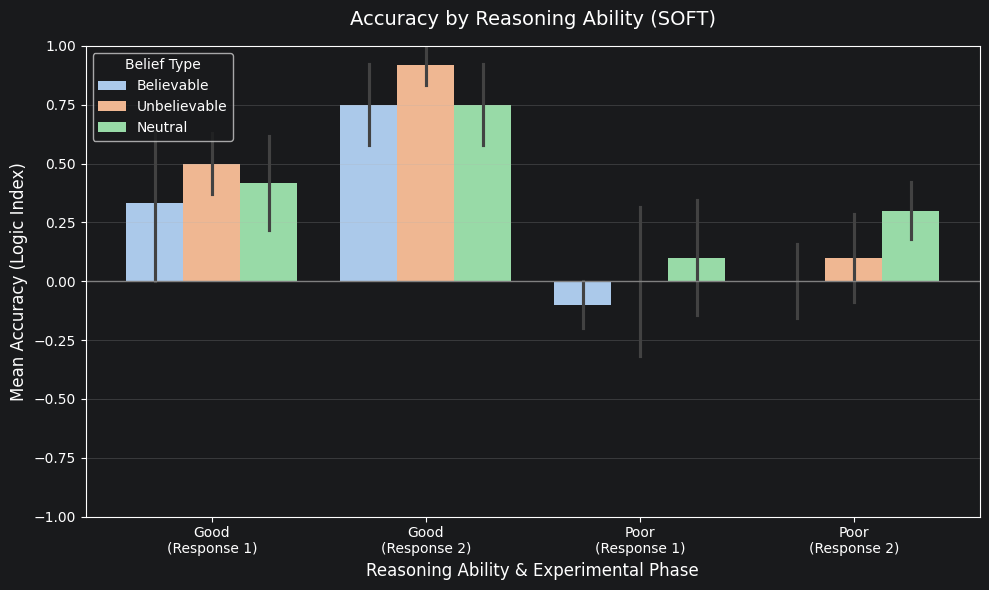

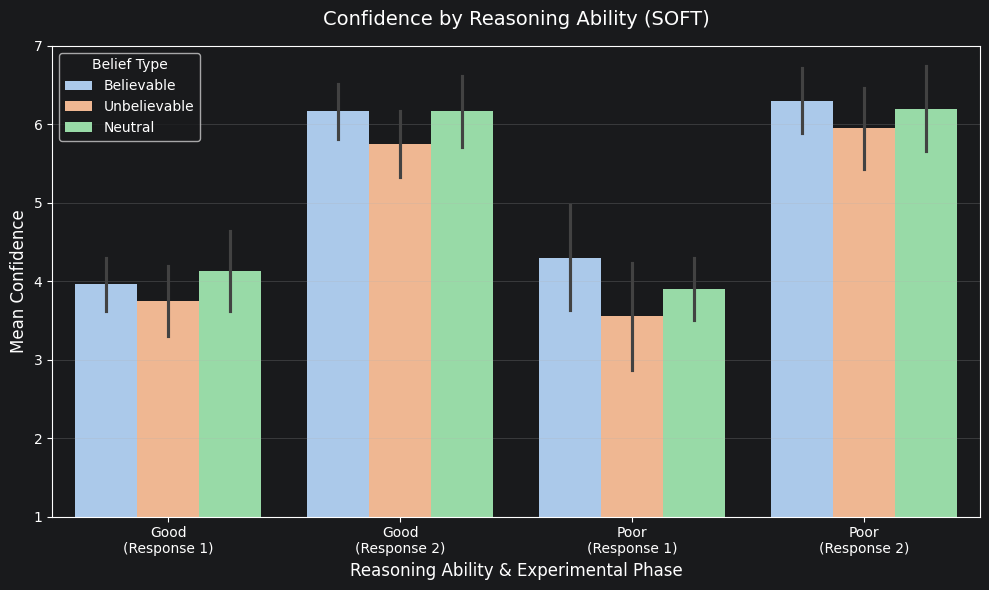

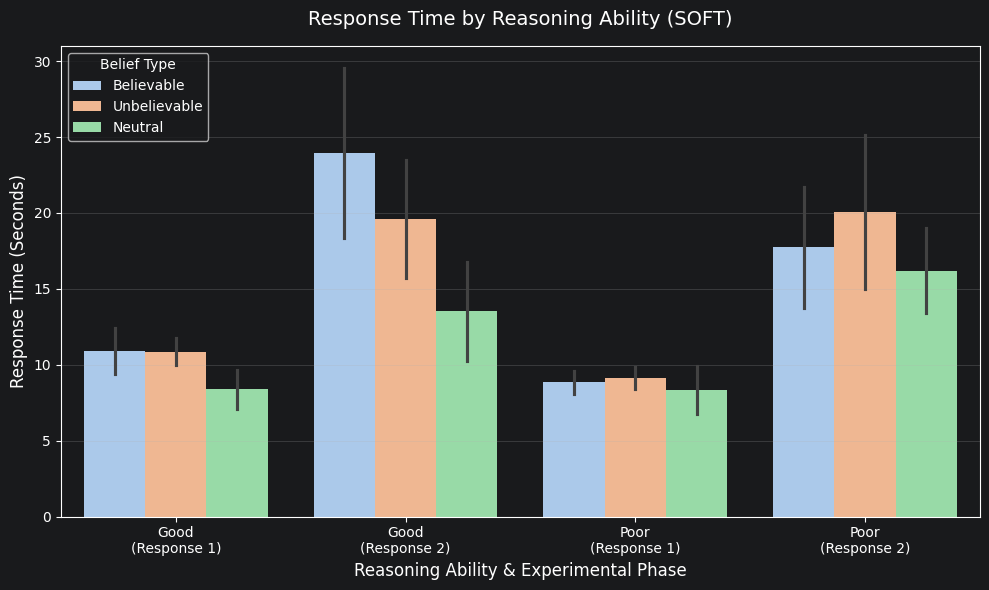

Generating Plots for STRICT Condition...


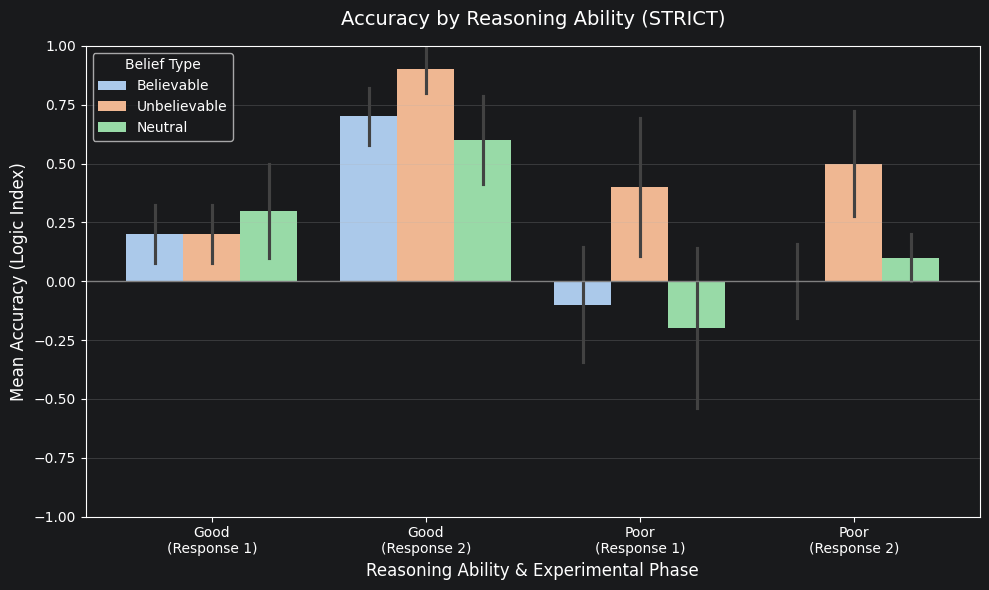

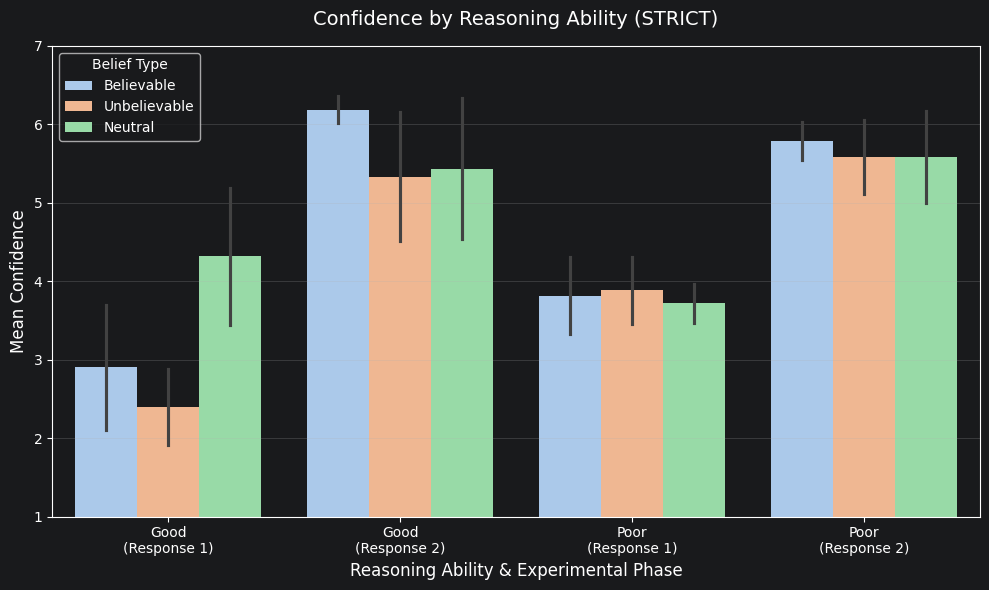

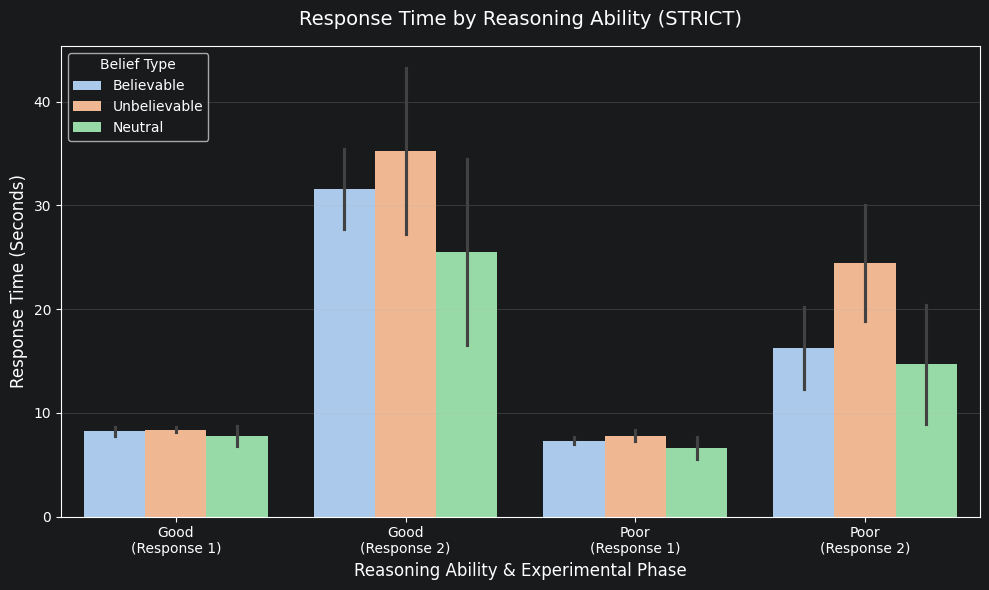

In [30]:
# 1. Create a specialized dataframe that preserves Belief Type for the nested plots
def agg_belief(group):
    # Extract exact RT columns and convert milliseconds to seconds
    rt1 = group['response1_rt_ms'].mean() / 1000 if 'response1_rt_ms' in group.columns else np.nan
    rt2 = group['final_rt_ms'].mean() / 1000 if 'final_rt_ms' in group.columns else np.nan

    return pd.Series({
        'logic_index_1': calc_logic_index(group, 'accept_phase1'),
        'logic_index_2': calc_logic_index(group, 'accept_phase2'),
        'confidence_1': get_conf(group, 1),
        'confidence_2': get_conf(group, 2),
        'rt_1': rt1,
        'rt_2': rt2
    })

# Group by participant, condition, and belief
df_plot = df_trials.groupby(['participant_code', 'assigned_condition', 'belief_type']).apply(agg_belief).reset_index()

# Merge the reasoner_type from our main participant dataframe so the Good/Poor splits align perfectly
df_plot = df_plot.merge(df_p[['participant_code', 'reasoner_type']], on='participant_code', how='left')
df_plot['belief_type'] = df_plot['belief_type'].str.capitalize()

# 2. Updated Plotting Function (Handles custom y-limits based on metric type)
def plot_bars_reasoning_ability(df, cols_to_compare, title, ylabel, y_limits=None):
    value_vars = list(cols_to_compare.values())
    rename_dict = {v: k for k, v in cols_to_compare.items()}

    df_long = pd.melt(
        df, id_vars=['reasoner_type', 'belief_type', 'participant_code', 'assigned_condition'],
        value_vars=value_vars, var_name='Phase', value_name='MetricValue'
    )
    df_long['Phase'] = df_long['Phase'].map(rename_dict)
    df_long['X_Axis'] = df_long['reasoner_type'] + "\n(" + df_long['Phase'] + ")"

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_long, x='X_Axis', y='MetricValue', hue='belief_type',
        hue_order=['Believable', 'Unbelievable', 'Neutral'],
        order=['Good\n(Response 1)', 'Good\n(Response 2)', 'Poor\n(Response 1)', 'Poor\n(Response 2)'],
        errorbar='se', palette='pastel'
    )

    # Only render horizontal zero-line for Accuracy (Logic Index) plots
    if y_limits == (-1, 1):
        plt.axline((0, 0), slope=0, color='gray', linestyle='-', linewidth=1)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Reasoning Ability & Experimental Phase", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    if y_limits:
        plt.ylim(y_limits)

    plt.legend(title='Belief Type', loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Generate the 6 Plots (Accuracy, Confidence, RT for both Strict & Soft conditions)
for cond in df_plot['assigned_condition'].unique():
    cond_df = df_plot[df_plot['assigned_condition'] == cond]
    print(f"Generating Plots for {cond.upper()} Condition...")

    # Plot Accuracy
    plot_bars_reasoning_ability(
        cond_df, {'Response 1': 'logic_index_1', 'Response 2': 'logic_index_2'},
        f"Accuracy by Reasoning Ability ({cond.upper()})", "Mean Accuracy (Logic Index)", y_limits=(-1, 1)
    )

    # Plot Confidence (if data exists)
    if cond_df['confidence_1'].notna().any():
        plot_bars_reasoning_ability(
            cond_df, {'Response 1': 'confidence_1', 'Response 2': 'confidence_2'},
            f"Confidence by Reasoning Ability ({cond.upper()})", "Mean Confidence", y_limits=(1, 7)
        )

    # Plot RT (if data exists)
    if cond_df['rt_1'].notna().any():
        plot_bars_reasoning_ability(
            cond_df, {'Response 1': 'rt_1', 'Response 2': 'rt_2'},
            f"Response Time by Reasoning Ability ({cond.upper()})", "Response Time (Seconds)"
        )

In [31]:
print("==========================================================")
print(" PART 3: THE BELIEF DISSOCIATION (ACCURACY VS CONFIDENCE) ")
print("==========================================================\n")

# 1. Aggregate metrics per participant AND belief type
def agg_belief_only(group):
    return pd.Series({
        'accuracy': calc_logic_index(group, 'accept_phase2'),
        'confidence': get_conf(group, 2)
    })

df_belief = df_trials.groupby(['participant_code', 'belief_type']).apply(agg_belief_only).reset_index()
df_belief['belief_type'] = df_belief['belief_type'].str.lower()

# 2. Pivot to wide format so each belief type is a column (makes paired t-tests easy)
df_acc_wide = df_belief.pivot(index='participant_code', columns='belief_type', values='accuracy').dropna()

print("--- 1. ACCURACY BY BELIEF TYPE ---")
print(f"Believable:   M = {df_acc_wide['believable'].mean():.3f}")
print(f"Unbelievable: M = {df_acc_wide['unbelievable'].mean():.3f}")
print(f"Neutral:      M = {df_acc_wide['neutral'].mean():.3f}")

# Paired t-test: Are they more accurate on Unbelievable vs Believable?
t_stat, p_val = stats.ttest_rel(df_acc_wide['unbelievable'], df_acc_wide['believable'])
print(f"Paired t-test (Unbelievable > Believable): t = {t_stat:.3f}, p = {p_val:.4f}\n")

# 3. Analyze Confidence (if the data exists)
if df_belief['confidence'].notna().any():
    df_conf_wide = df_belief.pivot(index='participant_code', columns='belief_type', values='confidence').dropna()

    print("--- 2. CONFIDENCE BY BELIEF TYPE ---")
    print(f"Believable:   M = {df_conf_wide['believable'].mean():.3f}")
    print(f"Unbelievable: M = {df_conf_wide['unbelievable'].mean():.3f}")
    print(f"Neutral:      M = {df_conf_wide['neutral'].mean():.3f}")

    # Paired t-test A: Do Believable and Unbelievable confidence differ? (Paper says NO)
    t_stat_1, p_val_1 = stats.ttest_rel(df_conf_wide['believable'], df_conf_wide['unbelievable'])
    print(f"Paired t-test (Believable vs Unbelievable): t = {t_stat_1:.3f}, p = {p_val_1:.4f}")

    # Paired t-test B: Is Belief-laden confidence higher than Neutral? (Paper says YES)
    # Average the two belief-laden conditions for each participant to compare against neutral
    belief_laden_conf = (df_conf_wide['believable'] + df_conf_wide['unbelievable']) / 2
    t_stat_2, p_val_2 = stats.ttest_rel(belief_laden_conf, df_conf_wide['neutral'])
    print(f"Paired t-test (Belief-Laden vs Neutral): t = {t_stat_2:.3f}, p = {p_val_2:.4f}\n")

 PART 3: THE BELIEF DISSOCIATION (ACCURACY VS CONFIDENCE) 

--- 1. ACCURACY BY BELIEF TYPE ---
Believable:   M = 0.381
Unbelievable: M = 0.619
Neutral:      M = 0.452
Paired t-test (Unbelievable > Believable): t = 2.500, p = 0.0212

--- 2. CONFIDENCE BY BELIEF TYPE ---
Believable:   M = 6.111
Unbelievable: M = 5.659
Neutral:      M = 5.861
Paired t-test (Believable vs Unbelievable): t = 2.209, p = 0.0390
Paired t-test (Belief-Laden vs Neutral): t = 0.099, p = 0.9223



In [32]:
import pandas as pd
from scipy import stats

print("==========================================================")
print(" PART 4: SUMMARY COMPARISON TABLE (STRICT VS SOFT)        ")
print("==========================================================\n")

# Dictionary mapping the dataframe columns to clean display names for the table
metrics_to_compare = {
    'accept_2': 'Acceptance Rate (Phase 2)',
    'answer_changed': 'Total Answer Change Rate',
    'yes_to_no': 'YES to NO Change Rate',
    'no_to_yes': 'NO to YES Change Rate',
    'logic_index_2': 'Accuracy (Logic Index Phase 2)',
    'accuracy_increase': 'Accuracy Increase (Phase 1 to 2)',
    'confidence_2': 'Confidence (Phase 2)',
    'rt_2': 'Response Time (s) (Phase 2)'
}

table_rows = []

# Isolate conditions
strict_p = df_p[df_p['assigned_condition'] == 'strict']
soft_p = df_p[df_p['assigned_condition'] == 'soft']

for col, display_name in metrics_to_compare.items():
    # Skip if the metric doesn't exist in the data (e.g., missing confidence or RT)
    if col not in df_p.columns or df_p[col].isna().all():
        continue

    strict_data = strict_p[col].dropna()
    soft_data = soft_p[col].dropna()

    if len(strict_data) == 0 or len(soft_data) == 0:
        continue

    # Calculate means
    mean_strict = strict_data.mean()
    mean_soft = soft_data.mean()

    # Run independent samples t-test (Welch's t-test for unequal variances)
    t_stat, p_val = stats.ttest_ind(strict_data, soft_data, equal_var=False)

    # Format p-value to APA standards
    p_str = "< .001" if p_val < 0.001 else f"{p_val:.3f}"

    # Append row
    table_rows.append({
        'Metric': display_name,
        'Strict (M)': f"{mean_strict:.3f}",
        'Soft (M)': f"{mean_soft:.3f}",
        't': f"{t_stat:.2f}",
        'p-value': p_str
    })

# Convert to DataFrame
comparison_table = pd.DataFrame(table_rows)

# Display as a clean HTML table in Jupyter
display(comparison_table)

 PART 4: SUMMARY COMPARISON TABLE (STRICT VS SOFT)        



,Metric,Strict (M),Soft (M),t,p-value
0,Acceptance Rate (Phase 2),0.644,0.644,0.01,0.996
1,Total Answer Change Rate,0.450,0.288,2.16,0.044
2,YES to NO Change Rate,0.142,0.152,-0.17,0.869
3,NO to YES Change Rate,0.175,0.136,0.65,0.526
4,Accuracy (Logic Index Phase 2),0.443,0.500,-0.37,0.714
5,Accuracy Increase (Phase 1 to 2),0.305,0.273,0.21,0.836
6,Confidence (Phase 2),5.717,6.083,-0.95,0.354
7,Response Time (s) (Phase 2),24.031,18.557,1.15,0.269


# Mouse Movement Analysis

In [35]:
import pandas as pd
import numpy as np
from scipy import stats

print("==========================================================")
print(" PART 5: MOUSE METRICS & S&T (2006) SPLIT BY CONDITION    ")
print("==========================================================\n")

# Define the exact mouse columns from the dataset
mouse_metrics = {
    'total_mouse_distance_phase1': 'Total Mouse Distance',
    'number_of_pauses_phase1': 'Number of Pauses',
    'number_of_direction_changes_phase1': 'Direction Changes'
}

# Helper to find the confidence column safely
conf_col = 'confidence1' if 'confidence1' in df_trials.columns else 'confidence_1'
if conf_col not in df_trials.columns and 'confidence_phase1' in df_trials.columns:
    conf_col = 'confidence_phase1'

# ---------------------------------------------------------
# S&T CONCLUSION 1: UNBELIEVABLE CONCLUSIONS TRIGGER OVERRIDE
# ---------------------------------------------------------
print("--- 1. BELIEF BIAS HESITATION (UNBELIEVABLE VS BELIEVABLE) ---")
# Aggregate by participant, condition, and belief type
df_mouse_belief = df_trials.groupby(['participant_code', 'assigned_condition', 'belief_type'])[list(mouse_metrics.keys())].mean().reset_index()
df_mouse_belief['belief_type'] = df_mouse_belief['belief_type'].str.lower()

for cond in df_trials['assigned_condition'].unique():
    print(f"\n>>> CONDITION: {cond.upper()} <<<")
    cond_df = df_mouse_belief[df_mouse_belief['assigned_condition'] == cond]

    for col, name in mouse_metrics.items():
        if col in cond_df.columns:
            wide_df = cond_df.pivot(index='participant_code', columns='belief_type', values=col).dropna()

            if 'unbelievable' in wide_df.columns and 'believable' in wide_df.columns:
                t_stat, p_val = stats.ttest_rel(wide_df['unbelievable'], wide_df['believable'])
                print(f"{name}:")
                print(f"  Unbelievable M = {wide_df['unbelievable'].mean():.2f} | Believable M = {wide_df['believable'].mean():.2f}")
                print(f"  Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

# ---------------------------------------------------------
# S&T CONCLUSION 2: LOW INITIAL CERTAINTY PREDICTS ANSWER CHANGES
# ---------------------------------------------------------
print("\n----------------------------------------------------------")
print("--- 2. DOES PHYSICAL HESITATION PREDICT CHANGING ANSWERS? ---")

# Ensure 'answer_changed' is calculated
if 'answer_changed' not in df_trials.columns:
    df_trials['answer_changed'] = (df_trials['response1'] != df_trials['final_response']).astype(int)

# Aggregate by participant, condition, AND whether they changed their answer
df_change = df_trials.groupby(['participant_code', 'assigned_condition', 'answer_changed'])[list(mouse_metrics.keys())].mean().reset_index()

for cond in df_trials['assigned_condition'].unique():
    print(f"\n>>> CONDITION: {cond.upper()} <<<")
    cond_df = df_change[df_change['assigned_condition'] == cond]

    for col, name in mouse_metrics.items():
        if col in cond_df.columns:
            kept = cond_df[cond_df['answer_changed'] == 0][col].dropna()
            changed = cond_df[cond_df['answer_changed'] == 1][col].dropna()

            if len(kept) > 0 and len(changed) > 0:
                t_stat, p_val = stats.ttest_ind(changed, kept, equal_var=False)
                print(f"{name} (Phase 1):")
                print(f"  When Answer Kept:    M = {kept.mean():.2f} (N={len(kept)})")
                print(f"  When Answer Changed: M = {changed.mean():.2f} (N={len(changed)})")
                print(f"  Independent t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

# ---------------------------------------------------------
# S&T CONCLUSION 3: CONFIDENCE VS PHYSICAL HESITATION
# ---------------------------------------------------------
print("\n----------------------------------------------------------")
print("--- 3. DOES SELF-REPORTED CONFIDENCE MATCH PHYSICAL HESITATION? ---")

if conf_col in df_trials.columns:
    # Aggregate to participant level overall, keeping track of condition
    df_conf_mouse = df_trials.groupby(['participant_code', 'assigned_condition'])[[conf_col] + list(mouse_metrics.keys())].mean().dropna().reset_index()

    for cond in df_trials['assigned_condition'].unique():
        print(f"\n>>> CONDITION: {cond.upper()} <<<")
        cond_df = df_conf_mouse[df_conf_mouse['assigned_condition'] == cond]

        for col, name in mouse_metrics.items():
            if col in cond_df.columns and len(cond_df) > 1:
                corr, p_val = stats.pearsonr(cond_df[col], cond_df[conf_col])
                print(f"Correlation: {name} vs Self-Reported Confidence (Phase 1):")
                print(f"  Pearson r = {corr:.3f}, p = {p_val:.4f}")
else:
    print("Confidence column for Phase 1 not found. Check column names.")

 PART 5: MOUSE METRICS & S&T (2006) SPLIT BY CONDITION    

--- 1. BELIEF BIAS HESITATION (UNBELIEVABLE VS BELIEVABLE) ---

>>> CONDITION: SOFT <<<
Total Mouse Distance:
  Unbelievable M = 1342.32 | Believable M = 1249.82
  Paired t-test: t = 0.775, p = 0.4562
Number of Pauses:
  Unbelievable M = 8.34 | Believable M = 7.70
  Paired t-test: t = 0.911, p = 0.3837
Direction Changes:
  Unbelievable M = 3.73 | Believable M = 3.14
  Paired t-test: t = 1.536, p = 0.1556

>>> CONDITION: STRICT <<<
Total Mouse Distance:
  Unbelievable M = 1198.12 | Believable M = 1062.95
  Paired t-test: t = 1.753, p = 0.1135
Number of Pauses:
  Unbelievable M = 6.35 | Believable M = 6.30
  Paired t-test: t = 0.105, p = 0.9186
Direction Changes:
  Unbelievable M = 2.80 | Believable M = 2.67
  Paired t-test: t = 0.422, p = 0.6831

----------------------------------------------------------
--- 2. DOES PHYSICAL HESITATION PREDICT CHANGING ANSWERS? ---

>>> CONDITION: SOFT <<<
Total Mouse Distance (Phase 1):
  When

In [34]:
import pandas as pd
import numpy as np
from scipy import stats

print("==========================================================")
print(" PART 6: MOUSE METRICS ALIGNED WITH S&T (2006) FINDINGS   ")
print("==========================================================\n")

# Define the exact mouse columns from the dataset
mouse_metrics = {
    'total_mouse_distance_phase1': 'Total Mouse Distance',
    'number_of_pauses_phase1': 'Number of Pauses',
    'number_of_direction_changes_phase1': 'Direction Changes'
}

# Helper to find the confidence column safely
conf_col = 'confidence1' if 'confidence1' in df_trials.columns else 'confidence_1'
if conf_col not in df_trials.columns and 'confidence_phase1' in df_trials.columns:
    conf_col = 'confidence_phase1'

# ---------------------------------------------------------
# S&T CONCLUSION 1: UNBELIEVABLE CONCLUSIONS TRIGGER ANALYTIC OVERRIDE
# ---------------------------------------------------------
print("--- 1. DOES BELIEF BIAS TRIGGER PHYSICAL HESITATION? ---")
print("(S&T 2006: Unbelievable statements trigger deeper analytic processing than Believable ones)\n")

# Aggregate by participant and belief type
df_mouse_belief = df_trials.groupby(['participant_code', 'belief_type'])[list(mouse_metrics.keys())].mean().reset_index()
df_mouse_belief['belief_type'] = df_mouse_belief['belief_type'].str.lower()

for col, name in mouse_metrics.items():
    if col in df_mouse_belief.columns:
        wide_df = df_mouse_belief.pivot(index='participant_code', columns='belief_type', values=col).dropna()
        if 'unbelievable' in wide_df.columns and 'believable' in wide_df.columns:
            t_stat, p_val = stats.ttest_rel(wide_df['unbelievable'], wide_df['believable'])
            print(f"{name}:")
            print(f"  Unbelievable M = {wide_df['unbelievable'].mean():.2f} | Believable M = {wide_df['believable'].mean():.2f}")
            print(f"  Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
            if p_val < 0.05 and t_stat > 0:
                print("  -> ALIGNS WITH S&T: Unbelievable statements cause significantly more physical hesitation.\n")
            else:
                print("  -> NO ALIGNMENT: Belief type did not significantly alter physical mouse hesitation.\n")

# ---------------------------------------------------------
# S&T CONCLUSION 2: LOW INITIAL CERTAINTY PREDICTS ANSWER CHANGES
# ---------------------------------------------------------
print("--- 2. DOES PHYSICAL HESITATION PREDICT CHANGING ANSWERS? ---")
print("(S&T 2006: Participants change their answers when their initial certainty is low)\n")

# Ensure 'answer_changed' is calculated
if 'answer_changed' not in df_trials.columns:
    df_trials['answer_changed'] = (df_trials['response1'] != df_trials['final_response']).astype(int)

# Aggregate by participant AND whether they changed their answer
df_change = df_trials.groupby(['participant_code', 'answer_changed'])[list(mouse_metrics.keys())].mean().reset_index()

for col, name in mouse_metrics.items():
    if col in df_change.columns:
        kept = df_change[df_change['answer_changed'] == 0][col].dropna()
        changed = df_change[df_change['answer_changed'] == 1][col].dropna()

        # Using independent t-test because some participants might have never changed an answer (no overlap)
        t_stat, p_val = stats.ttest_ind(changed, kept, equal_var=False)
        print(f"{name} (Phase 1):")
        print(f"  When Answer Kept:    M = {kept.mean():.2f} (N={len(kept)})")
        print(f"  When Answer Changed: M = {changed.mean():.2f} (N={len(changed)})")
        print(f"  Independent t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
        if p_val < 0.05 and t_stat > 0:
            print("  -> ALIGNS WITH S&T: High initial mouse conflict physically predicts a later answer change.\n")
        else:
            print("  -> NO ALIGNMENT: Initial mouse conflict does not predict changing answers.\n")

# ---------------------------------------------------------
# S&T CONCLUSION 3: CONFIDENCE VS PHYSICAL HESITATION
# ---------------------------------------------------------
print("--- 3. DOES SELF-REPORTED CONFIDENCE MATCH PHYSICAL HESITATION? ---")
print("(S&T 2006: Confidence is poorly calibrated. Let's see if it correlates with the mouse)\n")

if conf_col in df_trials.columns:
    # Aggregate to participant level overall
    df_conf_mouse = df_trials.groupby('participant_code')[[conf_col] + list(mouse_metrics.keys())].mean().dropna()

    for col, name in mouse_metrics.items():
        if col in df_conf_mouse.columns:
            corr, p_val = stats.pearsonr(df_conf_mouse[col], df_conf_mouse[conf_col])
            print(f"Correlation: {name} vs Self-Reported Confidence (Phase 1):")
            print(f"  Pearson r = {corr:.3f}, p = {p_val:.4f}")
            if p_val < 0.05 and corr < 0:
                print("  -> EXPECTED RESULT: More mouse hesitation strongly correlates with lower self-reported confidence.\n")
            elif p_val < 0.05 and corr > 0:
                print("  -> PARADOX: More mouse hesitation correlates with HIGHER confidence.\n")
            else:
                print("  -> S&T DISCONNECT: Physical hesitation (mouse) and conscious hesitation (confidence) are totally disconnected.\n")
else:
    print("Confidence column for Phase 1 not found. Check column names.")

 PART 6: MOUSE METRICS ALIGNED WITH S&T (2006) FINDINGS   

--- 1. DOES BELIEF BIAS TRIGGER PHYSICAL HESITATION? ---
(S&T 2006: Unbelievable statements trigger deeper analytic processing than Believable ones)

Total Mouse Distance:
  Unbelievable M = 1273.65 | Believable M = 1160.83
  Paired t-test: t = 1.591, p = 0.1272
  -> NO ALIGNMENT: Belief type did not significantly alter physical mouse hesitation.

Number of Pauses:
  Unbelievable M = 7.39 | Believable M = 7.04
  Paired t-test: t = 0.841, p = 0.4105
  -> NO ALIGNMENT: Belief type did not significantly alter physical mouse hesitation.

Direction Changes:
  Unbelievable M = 3.29 | Believable M = 2.92
  Paired t-test: t = 1.503, p = 0.1485
  -> NO ALIGNMENT: Belief type did not significantly alter physical mouse hesitation.

--- 2. DOES PHYSICAL HESITATION PREDICT CHANGING ANSWERS? ---
(S&T 2006: Participants change their answers when their initial certainty is low)

Total Mouse Distance (Phase 1):
  When Answer Kept:    M = 1211.

 PART 7: VISUALIZING MOUSE METRICS (PHASE 1 VS PHASE 2)   



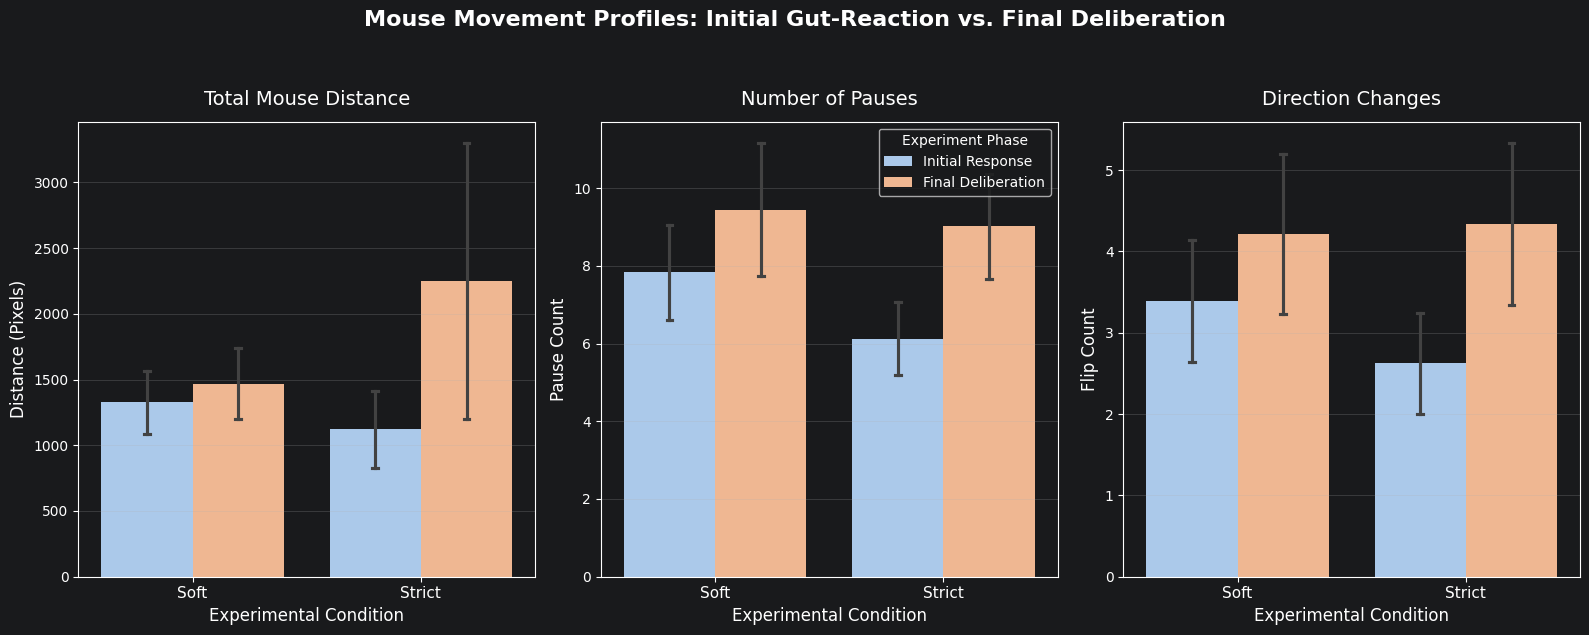

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("==========================================================")
print(" PART 7: VISUALIZING MOUSE METRICS (PHASE 1 VS PHASE 2)   ")
print("==========================================================\n")

# 1. Aggregate BOTH phases for the mouse metrics
def agg_mouse_both_phases(group):
    return pd.Series({
        'assigned_condition': group['assigned_condition'].iloc[0],

        # Initial Response (Phase 1)
        'dist_1': group['total_mouse_distance_phase1'].mean(),
        'pauses_1': group['number_of_pauses_phase1'].mean(),
        'dir_changes_1': group['number_of_direction_changes_phase1'].mean(),

        # Final Deliberation Response (Recorded as phase3 in the raw data)
        'dist_2': group['total_mouse_distance_phase3'].mean() if 'total_mouse_distance_phase3' in group.columns else np.nan,
        'pauses_2': group['number_of_pauses_phase3'].mean() if 'number_of_pauses_phase3' in group.columns else np.nan,
        'dir_changes_2': group['number_of_direction_changes_phase3'].mean() if 'number_of_direction_changes_phase3' in group.columns else np.nan
    })

df_mouse_both = df_trials.groupby('participant_code').apply(agg_mouse_both_phases).reset_index()

# 2. Set up the matplotlib figure (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics_to_plot = [
    ('dist', 'Total Mouse Distance', 'Distance (Pixels)'),
    ('pauses', 'Number of Pauses', 'Pause Count'),
    ('dir_changes', 'Direction Changes', 'Flip Count')
]

# Custom pastel palette to differentiate the phases
phase_palette = {'Initial Response': '#a1c9f4', 'Final Deliberation': '#ffb482'}

# 3. Loop through and plot each metric
for i, (base_col, title, ylabel) in enumerate(metrics_to_plot):

    # Melt the data into a long format for seaborn's hue grouping
    df_melt = pd.melt(
        df_mouse_both,
        id_vars=['participant_code', 'assigned_condition'],
        value_vars=[f'{base_col}_1', f'{base_col}_2'],
        var_name='Phase',
        value_name='Value'
    )

    # Rename the variables for clean legend labels
    df_melt['Phase'] = df_melt['Phase'].map({
        f'{base_col}_1': 'Initial Response',
        f'{base_col}_2': 'Final Deliberation'
    })

    # Render clustered bar plot
    sns.barplot(
        data=df_melt,
        x='assigned_condition',
        y='Value',
        hue='Phase',
        ax=axes[i],
        palette=phase_palette,
        errorbar='se',
        capsize=0.05,
        order=['soft', 'strict']
    )

    # Formatting
    axes[i].set_title(title, fontsize=14, pad=12)
    axes[i].set_xlabel("Experimental Condition", fontsize=12)
    axes[i].set_ylabel(ylabel, fontsize=12)
    axes[i].set_xticklabels(['Soft', 'Strict'], fontsize=11)
    axes[i].grid(axis='y', alpha=0.3)

    # Clean up the legends (only keep the legend on the middle plot to avoid clutter)
    if i == 1:
        axes[i].legend(title='Experiment Phase', loc='upper right')
    else:
        axes[i].get_legend().remove()

# Add a main overarching title
plt.suptitle("Mouse Movement Profiles: Initial Gut-Reaction vs. Final Deliberation", fontsize=16, y=1.05, fontweight='bold')

plt.tight_layout()
plt.show()

 PART 8: CONFIDENCE CALIBRATION & RESOLUTION 

--- T-TESTS: ABSOLUTE ACCURACY (CALIBRATION) & GAMMA (RESOLUTION) ---

(Note: Lower Absolute Accuracy = Better Calibration | Higher Gamma = Better Resolution)

Calibration (Absolute Accuracy) - Phase 1:
  Strict: M = 0.2835 | Soft: M = 0.2474
  t = 0.780, p = 0.4451

Resolution (Gamma) - Phase 1:
  Strict: M = 0.0070 | Soft: M = 0.5100
  t = -2.131, p = 0.0485

Calibration (Absolute Accuracy) - Phase 2:
  Strict: M = 0.2368 | Soft: M = 0.2189
  t = 0.277, p = 0.7854

Resolution (Gamma) - Phase 2:
  Strict: M = 0.1665 | Soft: M = 0.3666
  t = -0.592, p = 0.5641

Generating Calibration Plots...


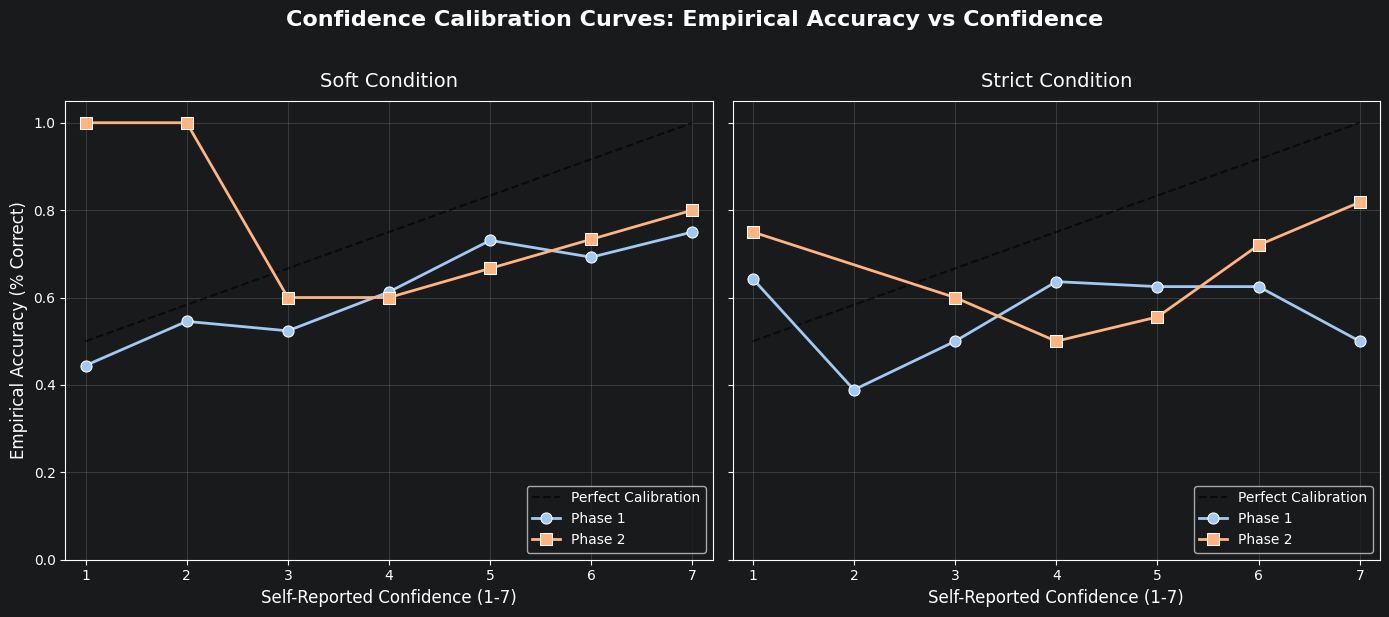

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("==========================================================")
print(" PART 8: CONFIDENCE CALIBRATION & RESOLUTION ")
print("==========================================================\n")

# 1. Define Correctness (1 = Correct, 0 = Incorrect)
df_trials['is_correct_1'] = (
    ((df_trials['validity'] == 'valid') & (df_trials['response1'] == 'YES')) |
    ((df_trials['validity'] == 'invalid') & (df_trials['response1'] == 'NO'))
).astype(int)

df_trials['is_correct_2'] = (
    ((df_trials['validity'] == 'valid') & (df_trials['final_response'] == 'YES')) |
    ((df_trials['validity'] == 'invalid') & (df_trials['final_response'] == 'NO'))
).astype(int)

# Safely find confidence columns
conf_col_1 = next((col for col in ['confidence1', 'confidence_1', 'confidence_phase1'] if col in df_trials.columns), None)
conf_col_2 = next((col for col in ['confidence2', 'confidence_2', 'confidence_phase2', 'confidence3', 'confidence_phase3'] if col in df_trials.columns), None)

if not conf_col_1 or not conf_col_2:
    print("⚠️ Could not find confidence columns in df_trials.")
else:
    # 2. Custom Goodman-Kruskal Gamma Function (Based on Course Slides)
    def calc_gamma(x, y):
        x = np.array(x)
        y = np.array(y)
        Ns = 0
        Nd = 0

        # Compare every unique pair of trials
        for i in range(len(x)):
            for j in range(i + 1, len(x)):
                dx = x[i] - x[j]
                dy = y[i] - y[j]

                if dx * dy > 0:
                    Ns += 1 # Concordant pair (Same order)
                elif dx * dy < 0:
                    Nd += 1 # Discordant pair (Inverse order)

        # If all pairs are ties, Gamma is undefined
        if (Ns + Nd) == 0:
            return np.nan

        return (Ns - Nd) / (Ns + Nd)

    # 3. Compute Course-Specific Metrics (Absolute Accuracy & Gamma)
    def compute_course_metrics(group, conf_col, acc_col):
        valid_trials = group.dropna(subset=[conf_col, acc_col])
        if len(valid_trials) < 2:
            return np.nan, np.nan

        # A. Calibration: Absolute Accuracy Index (Schraw, 2009)
        # Convert 1-7 confidence scale to a 0-1 probability scale to match performance (0 or 1)
        c_i = 0.5 + 0.5 * ((valid_trials[conf_col] - 1) / 6.0)
        p_i = valid_trials[acc_col]

        # Formula: (1/N) * sum((c_i - p_i)^2)
        absolute_accuracy_index = np.mean((c_i - p_i)**2)

        # B. Resolution: Goodman-Kruskal Gamma Coefficient
        gamma = calc_gamma(valid_trials[conf_col], valid_trials[acc_col])

        return absolute_accuracy_index, gamma

    def agg_calib_participant(group):
        cal_1, res_1 = compute_course_metrics(group, conf_col_1, 'is_correct_1')
        cal_2, res_2 = compute_course_metrics(group, conf_col_2, 'is_correct_2')
        return pd.Series({
            'assigned_condition': group['assigned_condition'].iloc[0],
            'abs_acc_1': cal_1, # Calibration Phase 1
            'gamma_1': res_1,   # Resolution Phase 1
            'abs_acc_2': cal_2,
            'gamma_2': res_2
        })

    df_calib_p = df_trials.groupby('participant_code').apply(agg_calib_participant).reset_index()

    # 4. Independent T-Tests (Strict vs. Soft)
    print("--- T-TESTS: ABSOLUTE ACCURACY (CALIBRATION) & GAMMA (RESOLUTION) ---\n")
    print("(Note: Lower Absolute Accuracy = Better Calibration | Higher Gamma = Better Resolution)\n")

    strict_cal = df_calib_p[df_calib_p['assigned_condition'] == 'strict']
    soft_cal = df_calib_p[df_calib_p['assigned_condition'] == 'soft']

    metrics_map = {
        'abs_acc_1': 'Calibration (Absolute Accuracy) - Phase 1',
        'gamma_1': 'Resolution (Gamma) - Phase 1',
        'abs_acc_2': 'Calibration (Absolute Accuracy) - Phase 2',
        'gamma_2': 'Resolution (Gamma) - Phase 2'
    }

    for col, name in metrics_map.items():
        strict_data = strict_cal[col].dropna()
        soft_data = soft_cal[col].dropna()

        if len(strict_data) > 0 and len(soft_data) > 0:
            t_stat, p_val = stats.ttest_ind(strict_data, soft_data, equal_var=False)
            print(f"{name}:")
            print(f"  Strict: M = {strict_data.mean():.4f} | Soft: M = {soft_data.mean():.4f}")
            print(f"  t = {t_stat:.3f}, p = {p_val:.4f}\n")

    # 5. Calibration Plots (Empirical vs. Confidence)
    print("Generating Calibration Plots...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle("Confidence Calibration Curves: Empirical Accuracy vs Confidence", fontsize=16, y=1.02, fontweight='bold')

    conditions = ['soft', 'strict']
    colors = {'Phase 1': '#a1c9f4', 'Phase 2': '#ffb482'}

    for i, cond in enumerate(conditions):
        cond_trials = df_trials[df_trials['assigned_condition'] == cond]

        # Calculate pooled empirical accuracy per confidence level for both phases
        cal_curve_1 = cond_trials.groupby(conf_col_1)['is_correct_1'].mean().reset_index()
        cal_curve_1.columns = ['Confidence', 'Accuracy']

        cal_curve_2 = cond_trials.groupby(conf_col_2)['is_correct_2'].mean().reset_index()
        cal_curve_2.columns = ['Confidence', 'Accuracy']

        # Perfect calibration benchmark line (1-7 mapped to 50%-100%)
        x_perfect = np.arange(1, 8)
        y_perfect = 0.5 + 0.5 * ((x_perfect - 1) / 6.0)

        axes[i].plot(x_perfect, y_perfect, 'k--', label='Perfect Calibration', alpha=0.6)

        # Plot Phase 1 & Phase 2
        sns.lineplot(data=cal_curve_1, x='Confidence', y='Accuracy', marker='o',
                     color=colors['Phase 1'], label='Phase 1', ax=axes[i], linewidth=2, markersize=8)
        sns.lineplot(data=cal_curve_2, x='Confidence', y='Accuracy', marker='s',
                     color=colors['Phase 2'], label='Phase 2', ax=axes[i], linewidth=2, markersize=8)

        axes[i].set_title(f"{cond.capitalize()} Condition", fontsize=14, pad=10)
        axes[i].set_xlabel("Self-Reported Confidence (1-7)", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Empirical Accuracy (% Correct)", fontsize=12)

        axes[i].set_ylim(0.0, 1.05)
        axes[i].set_xlim(0.8, 7.2)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='lower right')

    plt.tight_layout()
    plt.show()